# NSGD Evaluation Analysis
This notebook analyzes the performance of the NSGD policy using data from the `monitor.csv` log.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

In [2]:
# 1. Setup and Data Loading
log_path = '/home/kuscu/DRe-SCale/openfaas-functions/state-tracker/logs/nsgd_last_run/monitor.csv'
df = pd.read_csv(log_path)

# Normalize time columns for monitor.csv.
if 'datetime' in df.columns:
    df['datetime'] = pd.to_datetime(df['datetime'])
elif 'timestamp' in df.columns:
    df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
else:
    raise ValueError("monitor.csv must contain either 'datetime' or 'timestamp'")

# Calculate total initializing functions if not present.
if 'init_total' not in df.columns:
    df['init_total'] = df['init_free'] + df['init_reserved']

required_columns = ['idle_on', 'busy', 'init_total', 'init_reserved', 'datetime']
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"monitor.csv is missing required columns: {missing_columns}")

print(f"Rows: {len(df):,}")
print(f"Time range: {df['datetime'].min()} -> {df['datetime'].max()}")
print(f"Columns: {list(df.columns)}")
display(df.head())

Rows: 215,454
Time range: 2026-05-15 11:00:04 -> 2026-05-15 17:00:39
Columns: ['timestamp', 'datetime', 'cold', 'idle_on', 'busy', 'init_total', 'init_free', 'init_reserved', 'nsgd_cost', 'has_rejection', 'total_pods', 'ready_pods', 'not_ready_pods', 'inflight_requests', 'rejected_requests_interval', 'rejected_requests', 'latest_cost', 'cost_delta', 'iteration', 'phase']


,timestamp,datetime,cold,idle_on,busy,init_total,init_free,init_reserved,nsgd_cost,has_rejection,total_pods,ready_pods,not_ready_pods,inflight_requests,rejected_requests_interval,rejected_requests,latest_cost,cost_delta,iteration,phase
0,1.778843e+09,2026-05-15 11:00:04,23,1,0,0,0,0,2,False,1,1,0,0,0,0,NaN,NaN,NaN,NaN
1,1.778843e+09,2026-05-15 11:00:04,23,1,0,0,0,0,2,False,1,1,0,0,0,0,NaN,NaN,NaN,NaN
2,1.778843e+09,2026-05-15 11:00:04,23,1,0,0,0,0,2,False,1,1,0,0,0,0,NaN,NaN,NaN,NaN
3,1.778843e+09,2026-05-15 11:00:05,23,1,0,0,0,0,2,False,1,1,0,0,0,0,NaN,NaN,NaN,NaN
4,1.778843e+09,2026-05-15 11:00:05,23,1,0,0,0,0,2,False,1,1,0,0,0,0,NaN,NaN,NaN,NaN


Average Total Cost Overall: 15.98


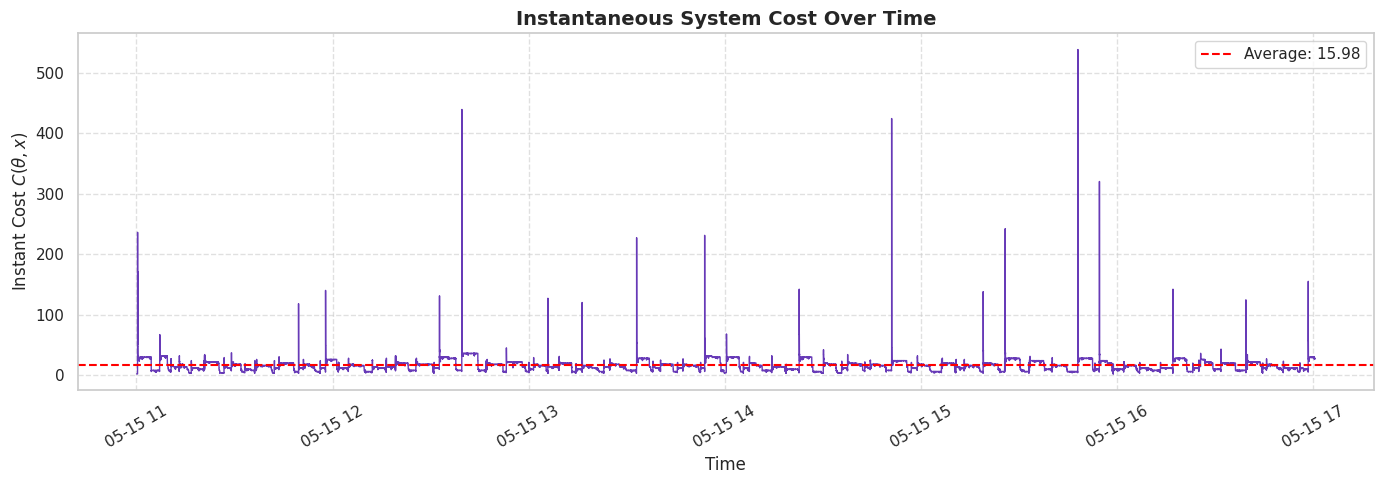

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define Weights and System Capacity
W_IDLE_ON = 2       
W_BUSY = 1          
W_INIT = 5          
W_RESERVED = 100    
W_REJ = 200         
MAX_REPLICAS = 50   # IMPORTANT: Change this to match your experiment's N!

# 2. Calculate individual instantaneous cost components
df['cost_idle'] = df['idle_on'] * W_IDLE_ON
df['cost_busy'] = df['busy'] * W_BUSY
df['cost_init'] = df['init_total'] * W_INIT
df['cost_reserved'] = df['init_reserved'] * W_RESERVED

# 3. THE FIX: Instantaneous Rejection Penalty (Indicator Function)
# Checks if the system is full at this exact moment (True=1, False=0)
df['is_saturated'] = (df['busy'] + df['init_reserved']) >= MAX_REPLICAS
df['cost_rejection'] = df['is_saturated'].astype(int) * W_REJ

# 4. Total Instantaneous Cost
# This now represents the exact C(theta, x) for every specific moment
df['total_instant_cost'] = df['cost_idle'] + df['cost_busy'] + df['cost_init'] + df['cost_reserved'] + df['cost_rejection']

# Calculate the true average
avg_cost = df['total_instant_cost'].mean()
print(f"Average Total Cost Overall: {avg_cost:.2f}")

optional_stats = {
    'Average Throughput': ('throughput', 'mean'),
    'Average Replicas': ('replicas', 'mean'),
    'Average Response Latency (ms)': ('avg_response_latency_ms', 'mean'),
    'Median Response Latency (ms)': ('avg_response_latency_ms', 'median'),
    'Average P99 Response Latency (ms)': ('p99_response_latency_ms', 'mean'),
    'Total Proxy Requests': ('proxy_requests', 'sum'),
    'Total Proxy Rejections': ('proxy_rejections', 'sum'),
}

for label, (column, agg) in optional_stats.items():
    if column in df.columns:
        value = getattr(df[column], agg)()
        print(f"{label}: {value:.2f}")

# --- Optional: Plot the instant cost over time ---
plt.figure(figsize=(14, 5))
plt.plot(df['datetime'], df['total_instant_cost'], color='#673AB7', linewidth=1)
plt.axhline(y=avg_cost, color='red', linestyle='--', linewidth=1.5, label=f'Average: {avg_cost:.2f}')

plt.title('Instantaneous System Cost Over Time', fontsize=14, fontweight='bold')
plt.ylabel('Instant Cost $C(\\theta, x)$')
plt.xlabel('Time')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

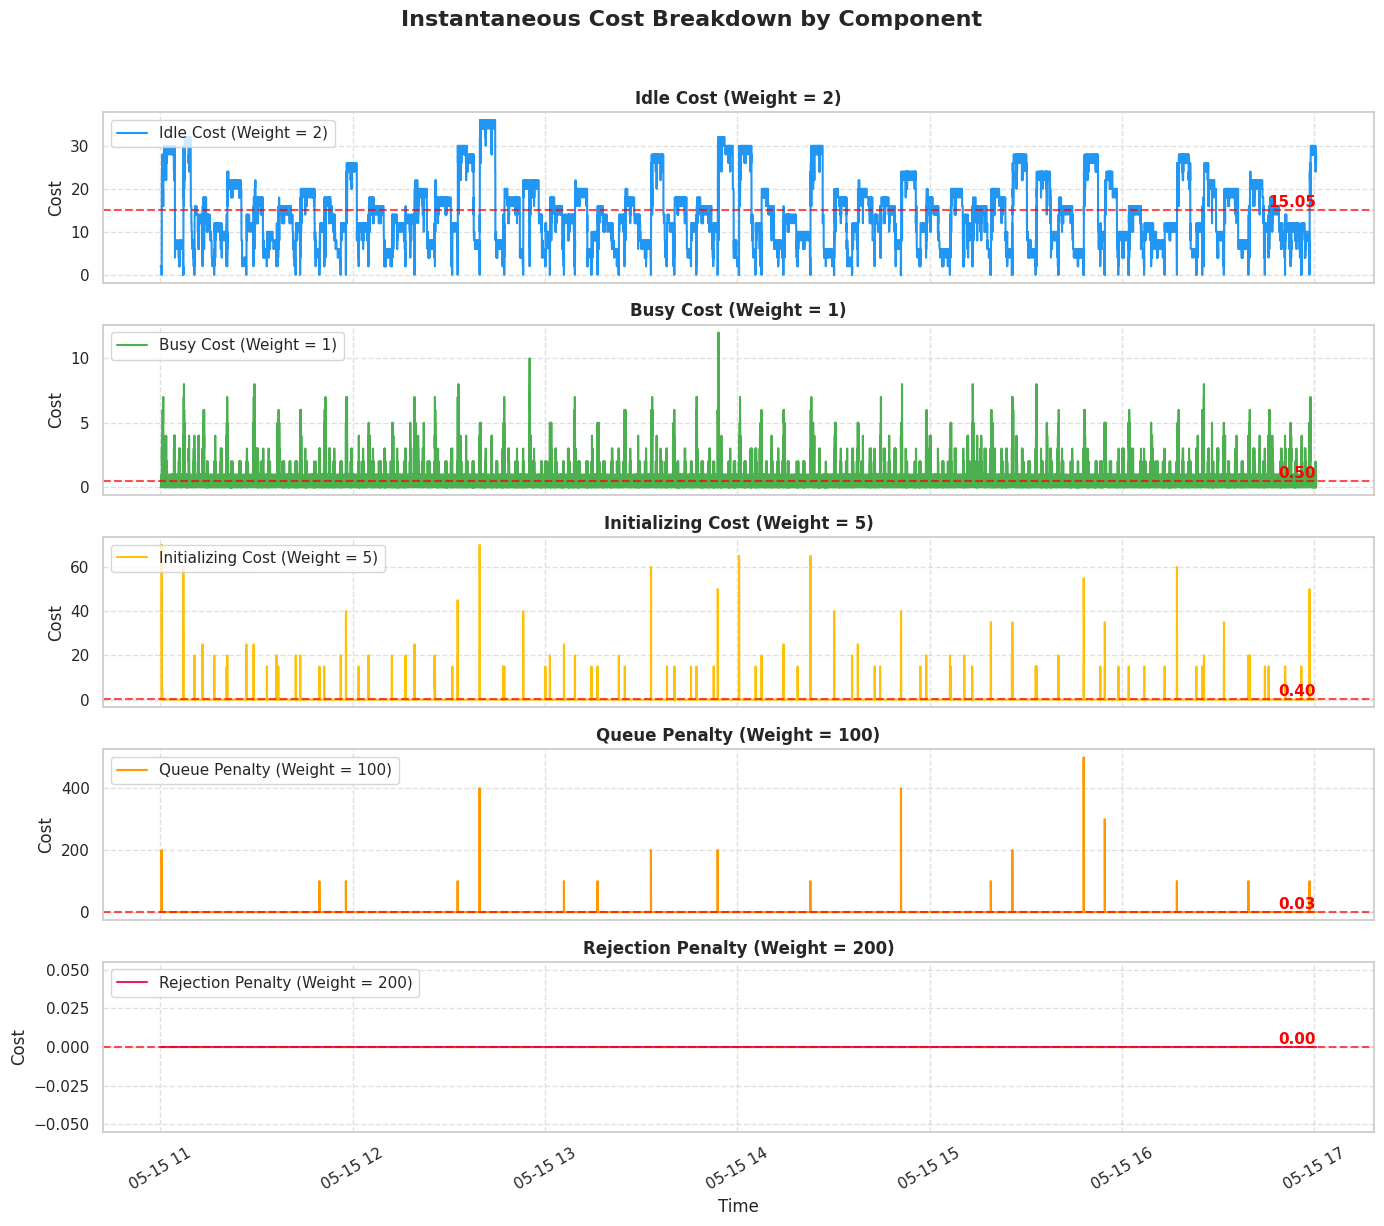

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# --- QUICK REMINDER ---
# Ensure your instantaneous rejection cost is calculated BEFORE running this!
# MAX_REPLICAS = 50 
# df['is_saturated'] = (df['busy'] + df['init_reserved']) >= MAX_REPLICAS
# df['cost_rejection'] = df['is_saturated'].astype(int) * W_REJ
# ----------------------

# Create 5 separate subplots that share the same X-axis (Time)
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

# Define the components to plot with their respective titles and colors
components = [
    ('cost_idle', 'Idle Cost (Weight = 2)', '#2196F3'),
    ('cost_busy', 'Busy Cost (Weight = 1)', '#4CAF50'),
    ('cost_init', 'Initializing Cost (Weight = 5)', '#FFC107'),
    ('cost_reserved', 'Queue Penalty (Weight = 100)', '#FF9800'),
    ('cost_rejection', 'Rejection Penalty (Weight = 200)', '#E91E63')
]

# Loop through each component and plot it on its own dedicated graph (ax)
for ax, (col, title, color) in zip(axes, components):
    # Plot the main line
    ax.plot(df['datetime'], df[col], color=color, linewidth=1.5, label=title)
    
    # Calculate and plot the individual average line
    avg_val = df[col].mean()
    ax.axhline(y=avg_val, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Add the text label for the average at the far right
    last_timestamp = df['datetime'].max()
    ax.text(last_timestamp, avg_val, f'{avg_val:.2f}', 
            color='red', va='bottom', ha='right', fontsize=11, fontweight='bold')
    
    # Formatting for each specific subplot
    ax.set_ylabel('Cost')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='upper left')

# Formatting for the overall layout
axes[-1].set_xlabel('Time') # Only put the 'Time' label on the very bottom graph
plt.xticks(rotation=30)
fig.suptitle('Instantaneous Cost Breakdown by Component', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Render the graphs
plt.show()